<a href="https://colab.research.google.com/github/Salman-Faris3090/Regression_Analysis/blob/main/PCRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Implement Principle Component Regression

In [2]:
import pandas as pd
import numpy as np
from scipy.linalg import svd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [4]:
# Load the CSV dataset (update the file path as needed)
file_path = '/content/predictive_maintenance.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Select relevant features and the target variable
features = data[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                 'Torque [Nm]', 'Tool wear [min]']].values
target = data['Target'].values  # Assuming 'Target' is the column name for the dependent variable


In [5]:
# Standardize the data (subtract mean and divide by standard deviation)
X_standardized = (features - np.mean(features, axis=0)) / np.std(features, axis=0)

In [6]:
# Step 1: Perform PCA using SVD
U, S, Vt = svd(X_standardized, full_matrices=False)

In [7]:
# Principal components (PCs) are given by U @ S
PCs = U @ np.diag(S)

In [8]:
# Step 2: Choose the number of principal components to retain (e.g., k = 3)
k = 3  # You can adjust k based on explained variance or trial/error
X_pca = PCs[:, :k]  # Use the first k principal components

In [9]:
# Add intercept term to the principal components
X_pca = np.hstack([np.ones((X_pca.shape[0], 1)), X_pca])

In [10]:
# Step 3: Define cost function for linear regression on principal components
def pcr_cost_function(theta, X_pca, y):
    m = len(y)
    predictions = X_pca @ theta
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [11]:
# Step 4: Minimize the cost function to find optimal theta (weights)
initial_theta = np.zeros(X_pca.shape[1])

In [12]:
# Optimize the cost function using scipy's minimize
result = minimize(pcr_cost_function, initial_theta, args=(X_pca, target), method='TNC')


In [13]:
# Optimal parameters (theta) found
optimal_theta = result.x

In [14]:
# Step 5: Predict using the principal components
def predict_pcr(X_pca, theta):
    return X_pca @ theta


In [15]:
# Make predictions on the principal components
predictions = predict_pcr(X_pca, optimal_theta)

In [16]:
# Evaluate model (e.g., R-squared)
rss = np.sum((target - predictions) ** 2)  # Residual sum of squares
tss = np.sum((target - np.mean(target)) ** 2)  # Total sum of squares
r_squared = 1 - rss / tss


In [17]:
# Print the results
print("Optimal theta (weights) for PCR:", optimal_theta)
print(f"R-squared for the PCR model: {r_squared:.4f}")

Optimal theta (weights) for PCR: [ 0.03389955 -0.00515995  0.0176346  -0.01876291]
R-squared for the PCR model: 0.0298


In [ ]:
#PLOTS

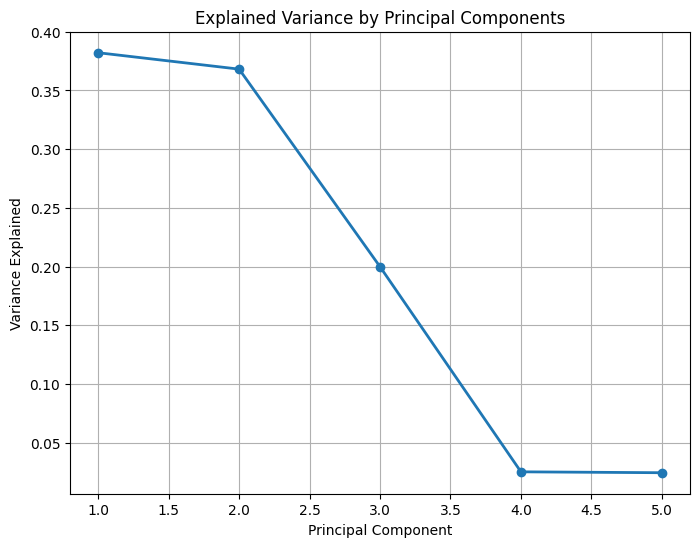

In [18]:
# 1. Explained Variance (Scree Plot)
explained_variance_ratio = (S ** 2) / np.sum(S ** 2)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(S)+1), explained_variance_ratio, 'o-', linewidth=2)
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

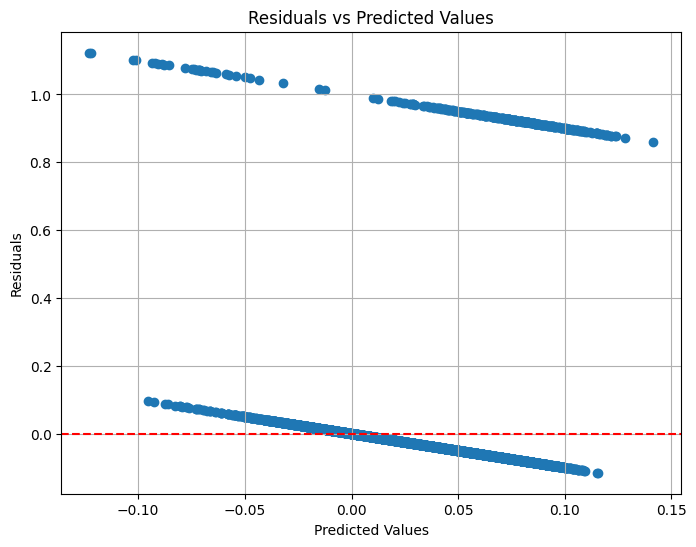

In [19]:
# 2. Residual Plot
residuals = target - predictions
plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

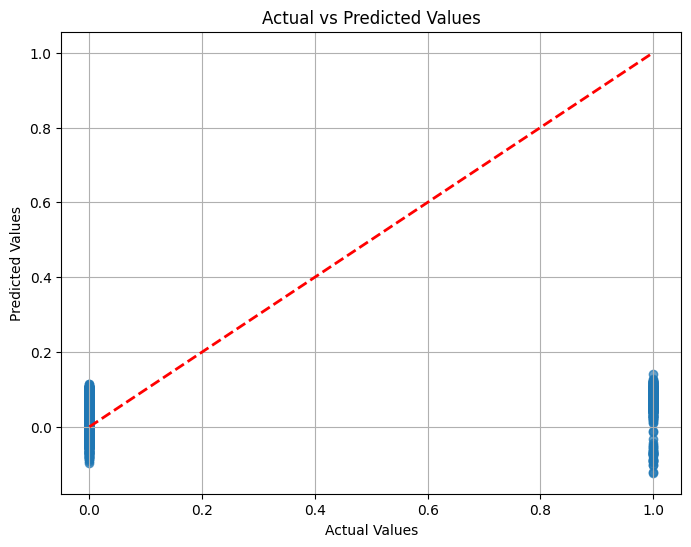

In [20]:
# 3. Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(target, predictions, alpha=0.7)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()